In [83]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import seaborn as sns

# plotting
import matplotlib.pyplot as plt
%matplotlib inline

# settings
plt.style.use('seaborn')
plt.rcParams["figure.figsize"] = (15, 5)

# Background

### About

Booking.com’s mission is to make it easier for everyone to experience the world. By investing in the technology that helps take the friction out of travel, Booking.com seamlessly connects millions of travellers with memorable experiences, a range of transport options and incredible places to stay.

Many of the travellers go on trips which include more than one destination. For instance, a user from the US could fly to Amsterdam for 5 nights, then spend 2 nights in Brussels, 3 in Paris and 1 in Amsterdam again before heading back home. In this scenario, we suggest options for extending their trip immediately when they make their booking.

The goal of this challenge is to use a dataset based on millions of real anonymized accommodation reservations to come up with a strategy for making the best recommendation for their next destination.
Booking.com releases this unique dataset to encourage the research on sequential recommendation problems.
### Evaluation criteria

The goal of the challenge is to predict (and recommend) the final city (city_id) of each trip (utrip_id). We will evaluate the quality of the predictions based on the top four recommended cities for each trip by using Top-4 Accuracy metric (4 representing the four suggestion slots at Booking.com website). When the true city is one of the top 4 suggestions (regardless of the order), it is considered correct.

# Data analysis

### Data Description

**user_id** - User ID   
**check-in** - Reservation check-in date   
**checkout** - Reservation check-out date   
**affiliate_id** - An anonymized ID of affiliate channels where the booker came from (e.g. direct, some third party referrals, paid search engine, etc.)   
**device_class** - desktop/mobile   
**booker_country** - Country from which the reservation was made (anonymized)   
**hotel_country** - Country of the hotel (anonymized)   
**city_id** - city_id of the hotel’s city (anonymized)   
**utrip_id** - Unique identification of user’s trip (a group of multi-destinations bookings within the same trip)

Each reservation is a part of a customer’s trip (identified by utrip_id) which includes at least 4 consecutive reservations. There are 0 or more days between check-out and check-in dates of two consecutive reservations.

The evaluation dataset is constructed similarly, however the city_id of the final reservation of each trip is concealed and requires a prediction.

In [84]:
df = pd.read_csv('../../datasets/booking/booking_train_set.csv.gz')

In [85]:
df.head()

,Unnamed: 0,user_id,checkin,checkout,city_id,device_class,affiliate_id,booker_country,hotel_country,utrip_id
0,0,1006220,2016-04-09,2016-04-11,31114,desktop,384,Gondal,Gondal,1006220_1
1,1,1006220,2016-04-11,2016-04-12,39641,desktop,384,Gondal,Gondal,1006220_1
2,2,1006220,2016-04-12,2016-04-16,20232,desktop,384,Gondal,Glubbdubdrib,1006220_1
3,3,1006220,2016-04-16,2016-04-17,24144,desktop,384,Gondal,Gondal,1006220_1
4,4,1010293,2016-07-09,2016-07-10,5325,mobile,359,The Devilfire Empire,Cobra Island,1010293_1


This is just sad. The guy who created the dataset forgot to put indec=False when saving the file. No worries.

In [86]:
df.drop(columns='Unnamed: 0',inplace=True)

In [87]:
df.shape

(1166835, 9)

In [88]:
df.dtypes

user_id            int64
checkin           object
checkout          object
city_id            int64
device_class      object
affiliate_id       int64
booker_country    object
hotel_country     object
utrip_id          object
dtype: object

In [101]:
# check for missing values
df.isnull().sum()

user_id           0
checkin           0
checkout          0
city_id           0
device_class      0
affiliate_id      0
booker_country    0
hotel_country     0
utrip_id          0
stay              0
dtype: int64

In [89]:
# convert int types to str as they are categorical values
df['user_id'] = df['user_id'].apply(lambda x: str(x))
df['city_id'] = df['city_id'].apply(lambda x: str(x))
df['affiliate_id'] = df['affiliate_id'].apply(lambda x: str(x))

In [90]:
df.describe()

,user_id,checkin,checkout,city_id,device_class,affiliate_id,booker_country,hotel_country,utrip_id
count,1166835,1166835,1166835,1166835,1166835,1166835,1166835,1166835,1166835
unique,200153,425,425,39901,3,3254,5,195,217686
top,2209265,2016-08-08,2016-08-10,47499,desktop,9924,Gondal,Cobra Island,3635431_3
freq,172,9672,9549,11242,753860,277775,536036,137791,48


Obs:  
1. 200k users making 1.16 million stays. **This is 5.8 stays on averge per user**
2. 425 days or 14 months of data
3. Almost 40k cities
4. 3 kinds of device used - Mobile, desktop and what is the 3rd?
5. Booker come from 3k different sources
6. Data covers users from 5 countries (anonymised) and they book hotel in 195 countries (virtually all the countries that are there on this earth)
7. The number of the trips is slighlty more than the number of users. **So most users seemed to have just made 1 trip, and few (217686-200153=17533) seems to have made more than 1. Average number of stays per trip is (1166835/217686 = 5.36)**

## Time analysis

#### Date ranges

In [92]:
# conver to datetime
df['checkin'] = pd.to_datetime(df['checkin'])
df['checkout'] = pd.to_datetime(df['checkout'])

In [93]:
print ('Checkin date range:',df['checkin'].min(),df['checkin'].max())
print ('Checkout date range:',df['checkout'].min(),df['checkout'].max())

Checkin date range: 2015-12-31 00:00:00 2017-02-27 00:00:00
Checkout date range: 2016-01-01 00:00:00 2017-02-28 00:00:00


#### Stay time frequency

In [94]:
df['stay'] = (df['checkout']-df['checkin']).dt.days

In [95]:
df['stay'].max()

30

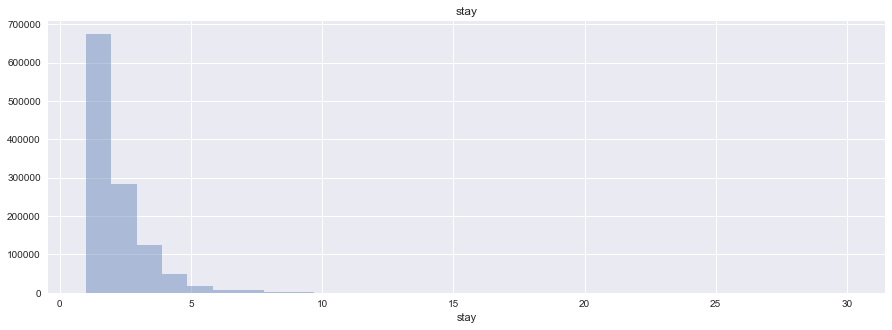

In [96]:
plt.figure()
plt.title('stay')
ax = sns.distplot(df['stay'],bins=30,kde=False)
plt.show()

Obs: Most stays last till 5 days. Max is 30 days

#### Stays by checkin and checkout dates

<AxesSubplot:>

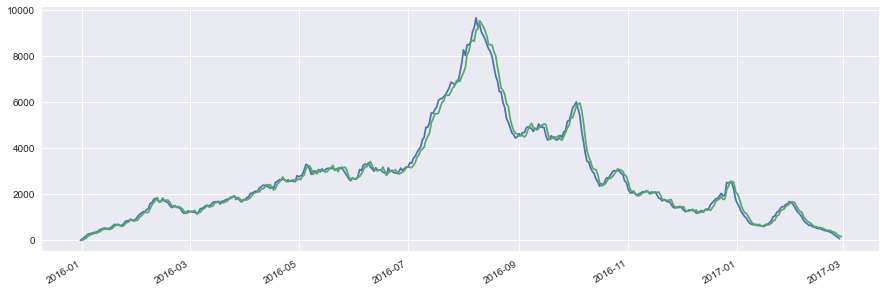

In [98]:
df['checkin'].value_counts().plot()
df['checkout'].value_counts().plot()

Obs: There are some peak in number of stays. Though we should take this in the context that this for trips that have atleast 4 stays

## Frequency analysis

In [99]:
df.columns

Index(['user_id', 'checkin', 'checkout', 'city_id', 'device_class',
       'affiliate_id', 'booker_country', 'hotel_country', 'utrip_id', 'stay'],
      dtype='object')

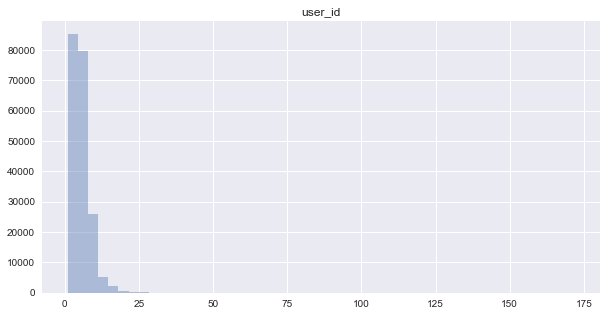

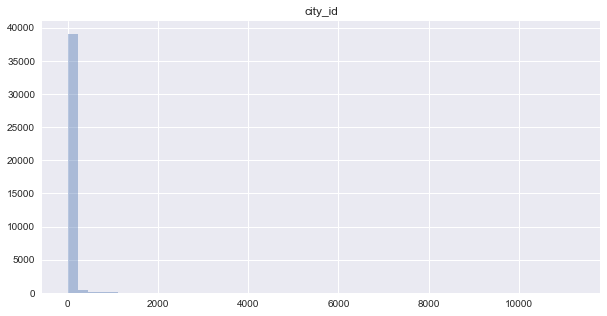

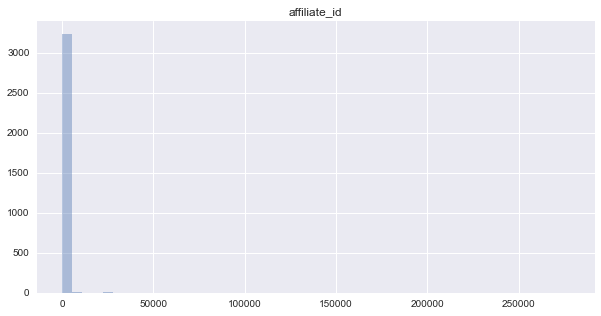

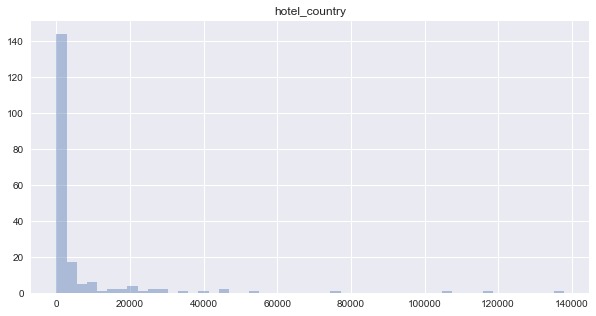

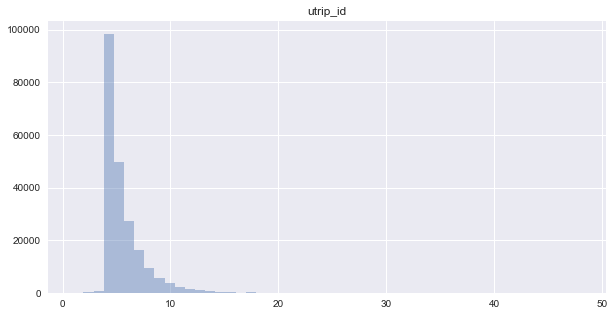

In [60]:
for col in ['user_id','city_id','affiliate_id','hotel_country','utrip_id']:
    plt.figure()
    plt.title(col)
    ax = sns.distplot(pd.DataFrame(df[col].value_counts()),kde=False)
    plt.show()

1. Number of stays in 14 months mostly remain less than 20. Someone has 175'ish stays. Looks cooky
2. 